# Assignment Instructions - Part 2: Phantom Data and Noise in a Model Component

In Part 1, we worked with symbolic expressions and explored how model parameters influence behavior. In this part, we shift to a different but closely related question: what happens when we observe a model through noisy measurements instead of exact equations?

The big idea is simple: if we know the truth, we can practice interpretation before we face messy real-world data.

We are going to do this with a single-file module in this directory: `generate_dataset.py`. First, import the libraries we plan to use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import generate_dataset as gd

sp.init_printing()

***TODO:*** Take a look at the `generate_dataset.py` file in the current directory. Notice where the descriptive text comes from when we use the `help` function on the module. Then change the comment at the top of the file with something you will recognize (for example, "HELLO WORLD"), reset the kernel, and run the help message again. You should be able to see your edits.

In [2]:
help(gd)

Help on module generate_dataset:

NAME
    generate_dataset - data_generator.py

DESCRIPTION
    Utilities for generating synthetic ("phantom") datasets from known
    analytical models.

    This module is used throughout the CMSE 802 analytical modeling unit.
    It supports activities involving:

    - model identification
    - parameter estimation
    - optimization
    - symbolic regression
    - testing and validation

    The key idea is that we can generate observations from a known model,
    hide the generating equation, and then attempt to recover the model
    from the resulting data.

    Examples
    --------
    Generate a random dataset:

    >>> data, truth = generate_dataset(seed=42)

    Generate a specific model:

    >>> data, truth = generate_dataset(
    ...     model_name="exponential",
    ...     seed=42
    ... )

    Inspect the generated data:

    >>> data.head()

    View the hidden model information:

    >>> truth

    Notes
    -----
    The returned 

## Generating Data using our library

We will do this in four small steps:

1. Generate one synthetic dataset using `generate_dataset`.
2. Inspect both outputs (`data` and `truth`).
3. Build a noise-free curve with `generate_truth_dataset`.
4. Plot noisy observations and truth together.

***TODO:*** Before running code, discuss in your group what you expect noise to change and what you expect to stay stable.

In [4]:
# Generate one synthetic dataset
data, truth = gd.generate_dataset(
    model_name="exponential",
    seed=42,
    n_points=60,
    noise_fraction=0.10,
 )

display(data.head())
truth

,x,y
0,1.000000,63.395882
1,1.322034,58.936511
2,1.644068,49.897457
3,1.966102,46.876174
4,2.288136,45.419500


{'model_name': 'exponential',
 'parameters': {'A': 79.6560443700367, 'k': 0.24749529788842356},
 'seed': 42,
 'noise_fraction': 0.1,
 'n_points': 60}

### Inspect the Returned Objects

Use `type`, `dir`, and `help` to inspect `data`, `truth`, and the helper functions.

***TODO:*** In your group, identify which pieces of information in `truth` would not usually be available in real measurements.

In [ ]:
# Put your exploration code here. Make more celplt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")ls as needed and share your progress with your team. 

In [12]:
type(truth)

dict

In [13]:
dir(truth)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [14]:
help(truth)

Help on dict object:

class dict(object)
 |  dict() -> new empty dictionary
 |  dict(mapping) -> new dictionary initialized from a mapping object's
 |      (key, value) pairs
 |  dict(iterable) -> new dictionary initialized as if via:
 |      d = {}
 |      for k, v in iterable:
 |          d[k] = v
 |  dict(**kwargs) -> new dictionary initialized with the name=value pairs
 |      in the keyword argument list.  For example:  dict(one=1, two=2)
 |
 |  Methods defined here:
 |
 |  __contains__(self, key, /)
 |      True if the dictionary has the specified key, else False.
 |
 |  __delitem__(self, key, /)
 |      Delete self[key].
 |
 |  __eq__(self, value, /)
 |      Return self==value.
 |
 |  __ge__(self, value, /)
 |      Return self>=value.
 |
 |  __getitem__(self, key, /)
 |      Return self[key].
 |
 |  __gt__(self, value, /)
 |      Return self>value.
 |
 |  __init__(self, /, *args, **kwargs)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __ior__(self

# Have a Look
The following code should plot the generated data.

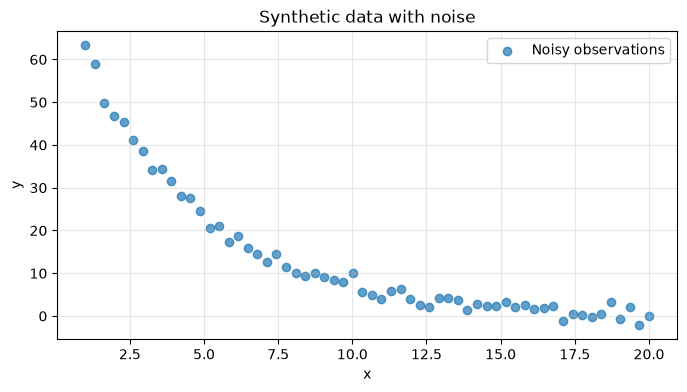

In [6]:
plt.figure(figsize=(8, 4))
plt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data with noise")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Plot Noisy Data vs Noise-Free Truth

The `generate_truth_dataset` function creates a NumPy array with truth data. Copy/paste the plotting code above and plot the truth data next to the synthetic data.

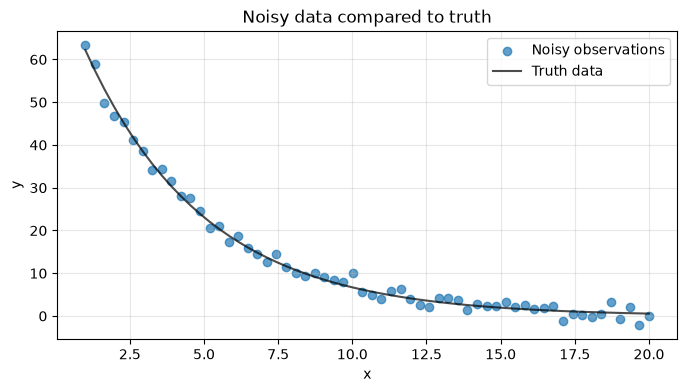

In [20]:
truth_data = gd.generate_truth_dataset(truth)
#TODO: Copy, paste and modify the above code here to see truth and synthetic side by side.  
# I recommend you use plot instead of scatter (maybe try both and see which you prefer)

plt.figure(figsize=(8, 4))
plt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")
plt.plot(truth_data["x"], truth_data["y"], alpha=0.7, label="Truth data", color = "black")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy data compared to truth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Explore the Library Functions

Spend some time exploring the functions inside `generate_dataset.py`. Play around with the random seed and see how that changes outputs. Share your exploration with your team and be ready to answer the following questions in class.
- What happens if you set `noise_fraction` really high?
- What happens if you set `noise_fraction` over 1? What might that mean?
- What happens if you set `noise_fraction` to less than 0? What does that error tell you?
- How might you use code like this in your own research?

# Advanced Example: Mini Code Review

Now look directly at `generate_dataset.py` and do a mini code review as a group.

The goal is not to rewrite the file. The goal is to understand how the file works and how your tools (`help` and `dir`) reveal what is inside the module.

***TODO:*** As a group, walk through one complete path in the file: 

> inputs -> validation -> model generation -> noise -> returned outputs.

Discussion questions for group share-out:

1. What does `help(generate_dataset)` tell you about expected inputs, defaults, and behavior?
2. What does `dir()` reveal that is defined in the file, and what important things does it not tell you?
3. Where are the guardrails (input validation) in the file, and what student mistakes do they prevent?
4. Which design choice in the file most supports reproducibility, and why?
5. If you had to improve one thing for readability without adding complexity, what would you change?

In [22]:
# Mini review helper commands (run and discuss as a group)
import generate_dataset as gd

print("Module-level names from dir():")
print([name for name in dir(gd) if not name.startswith('_')])

print("\nFunction help for generate_dataset:")
help(gd.generate_dataset)

Module-level names from dir():
['MODELS', 'annotations', 'available_models', 'evaluate_truth', 'exponential', 'generate_dataset', 'generate_truth_dataset', 'linear', 'logarithmic', 'np', 'pd', 'quadratic']

Function help for generate_dataset:
Help on function generate_dataset in module generate_dataset:

generate_dataset(
    model_name: str | None = None,
    seed: int = 42,
    n_points: int = 50,
    noise_fraction: float = 0.1
) -> tuple[pd.DataFrame, dict[str, object]]
    Generate a synthetic dataset.

    Parameters
    ----------
    model_name
        Name of the model family to use. If ``None``,
        a model is selected randomly.

    seed
        Random seed used for repeatable dataset generation.

    n_points
        Number of observations to generate.

    noise_fraction
        Standard deviation of the noise as a fraction of the
        model's natural variation.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing columns:

        - ``x``
    

#Put your group Thoughts here and be prepared to discuss as a class. 

If your team is done with this, go ahead and move on to Part 3.